# CIFAR-10 Adversarial Attacks with PyTorch

This notebook extends the PyTorch adversarial-attack workflow from MNIST to CIFAR-10. A convolutional neural network is trained on color images and evaluated under random noise, FGSM, targeted FGSM, BIM, and targeted BIM.


## Imports and Device


In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.metrics import accuracy_score, confusion_matrix

import torch
import torch.nn as nn

np.random.seed(42)
torch.manual_seed(42)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Using device:", device)


Using device: cuda


## Load and Prepare CIFAR-10


In [2]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

y_train = y_train.squeeze()
y_test = y_test.squeeze()

# Keep the complete training set and use the first 1,000
# test images for the attack experiments, matching the source workflow.
X_test = X_test[:1000]
y_test = y_test[:1000]

X_train = np.moveaxis(
    X_train,
    -1,
    1,
).astype("float32") / 255.0

X_test = np.moveaxis(
    X_test,
    -1,
    1,
).astype("float32") / 255.0

X_train_t = torch.tensor(
    X_train,
    dtype=torch.float32,
    device=device,
)

X_test_t = torch.tensor(
    X_test,
    dtype=torch.float32,
    device=device,
)

y_train_t = torch.tensor(
    y_train,
    dtype=torch.long,
    device=device,
)

y_test_t = torch.tensor(
    y_test,
    dtype=torch.long,
    device=device,
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2020s 12us/step
X_train: (50000, 3, 32, 32)
X_test: (1000, 3, 32, 32)


## CIFAR-10 Convolutional Classifier


In [3]:
class ConvNN(nn.Module):
    def __init__(
        self,
        conv_layers=(3, 50, 100, 200),
        dense_units=100,
    ):
        super().__init__()

        layers = []

        for i in range(1, len(conv_layers)):
            layers.extend(
                [
                    nn.Conv2d(
                        conv_layers[i - 1],
                        conv_layers[i],
                        kernel_size=3,
                        padding=1,
                    ),
                    nn.ReLU(),
                    nn.Conv2d(
                        conv_layers[i],
                        conv_layers[i],
                        kernel_size=3,
                        padding=1,
                    ),
                    nn.ReLU(),
                    nn.MaxPool2d(
                        kernel_size=2,
                        stride=2,
                    ),
                ]
            )

        self.features = nn.Sequential(*layers)

        # 32x32 -> 16x16 -> 8x8 -> 4x4 with 200 channels
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(
                4 * 4 * 200,
                dense_units,
            ),
            nn.ReLU(),
            nn.Linear(
                dense_units,
                10,
            ),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


model = ConvNN().to(device)
print(model)


ConvNN(
  (features): Sequential(
    (0): Conv2d(3, 50, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(50, 50, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(50, 100, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): Conv2d(100, 100, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU()
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(100, 200, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU()
    (12): Conv2d(200, 200, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU()
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3200, out_features=100, bias=True)
    (2): ReLU()
    

## Train the CIFAR-10 Classifier


In [4]:
loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
)

num_epochs = 10
batch_size = 100
n_train = len(X_train_t)

history = {
    "accuracy": [],
    "loss": [],
    "val_accuracy": [],
    "val_loss": [],
}

start_time = time.time()

for epoch in range(1, num_epochs + 1):
    model.train()

    permutation = torch.randperm(
        n_train,
        device=device,
    )

    total_loss = 0.0
    correct = 0

    for start_idx in range(0, n_train, batch_size):
        idx = permutation[start_idx:start_idx + batch_size]

        optimizer.zero_grad()

        logits = model(X_train_t[idx])

        loss = loss_function(
            logits,
            y_train_t[idx],
        )

        loss.backward()
        optimizer.step()

        total_loss += (
            loss.item()
            * len(idx)
        )

        correct += (
            logits.argmax(dim=1)
            == y_train_t[idx]
        ).sum().item()

    train_loss = total_loss / n_train
    train_acc = correct / n_train

    model.eval()

    with torch.no_grad():
        test_logits = model(X_test_t)

        test_loss = loss_function(
            test_logits,
            y_test_t,
        ).item()

        test_acc = (
            test_logits.argmax(dim=1)
            == y_test_t
        ).float().mean().item()

    history["loss"].append(train_loss)
    history["accuracy"].append(train_acc)
    history["val_loss"].append(test_loss)
    history["val_accuracy"].append(test_acc)

    print(
        f"Epoch {epoch:2d}/{num_epochs}  "
        f"accuracy={train_acc:.4f}  "
        f"loss={train_loss:.6f}  "
        f"test_accuracy={test_acc:.4f}  "
        f"test_loss={test_loss:.6f}"
    )

print(
    "Elapsed training time:",
    f"{time.time() - start_time:.2f} s",
)


Epoch  1/10  accuracy=0.3495  loss=1.751319  test_accuracy=0.4770  test_loss=1.402342
Epoch  2/10  accuracy=0.5685  loss=1.195792  test_accuracy=0.6390  test_loss=1.023952
Epoch  3/10  accuracy=0.6631  loss=0.950460  test_accuracy=0.7060  test_loss=0.844970
Epoch  4/10  accuracy=0.7202  loss=0.793924  test_accuracy=0.7260  test_loss=0.780316
Epoch  5/10  accuracy=0.7587  loss=0.687361  test_accuracy=0.7480  test_loss=0.740282
Epoch  6/10  accuracy=0.7928  loss=0.595479  test_accuracy=0.7700  test_loss=0.651911
Epoch  7/10  accuracy=0.8185  loss=0.520755  test_accuracy=0.7590  test_loss=0.702331
Epoch  8/10  accuracy=0.8416  loss=0.450062  test_accuracy=0.7680  test_loss=0.726787
Epoch  9/10  accuracy=0.8626  loss=0.392092  test_accuracy=0.7710  test_loss=0.708965
Epoch 10/10  accuracy=0.8841  loss=0.328578  test_accuracy=0.7720  test_loss=0.724592
Elapsed training time: 22.06 s


## Class-Wise Examples and Display Conversion


In [5]:
sample = [[] for _ in range(10)]

for i, y in enumerate(y_test):
    sample[int(y)].append(i)

rng = np.random.default_rng(42)

random_sel = [
    sample[class_id][rng.integers(0, len(sample[class_id]))]
    for class_id in range(10)
]

class_names = [
    "airplane",
    "car",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
]


def channels_last(image):
    return np.moveaxis(
        image,
        0,
        -1,
    )


## Sample Random Perturbations


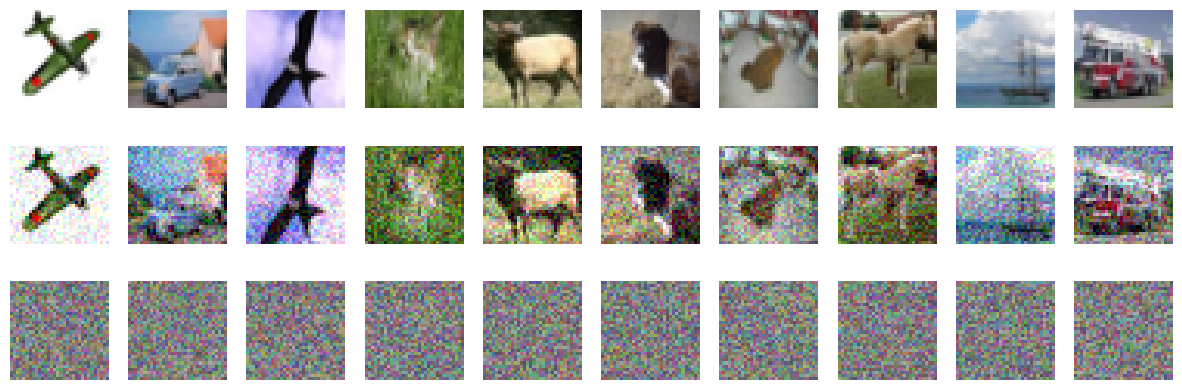

In [6]:
noise = np.random.uniform(
    -0.2,
    0.2,
    size=X_test.shape,
).astype("float32")

X_test_noisy = np.clip(
    X_test + noise,
    0.0,
    1.0,
)

fig, ax = plt.subplots(
    3,
    10,
    figsize=(15, 5),
)

for col, index in enumerate(random_sel):
    ax[0, col].imshow(
        channels_last(
            X_test[index]
        )
    )
    ax[0, col].axis("off")

    ax[1, col].imshow(
        channels_last(
            X_test_noisy[index]
        )
    )
    ax[1, col].axis("off")

    ax[2, col].imshow(
        np.clip(
            channels_last(noise[index])
            + 0.5,
            0,
            1,
        )
    )
    ax[2, col].axis("off")

plt.show()


# Random-Noise Attack


In [7]:
def random_noise_attack(
    model,
    X,
    y,
    goal_accuracy=0.5,
    max_steps=200,
):
    model.eval()

    for i in range(1, max_steps):
        epsilon = i / max_steps

        noise = np.random.uniform(
            -epsilon,
            epsilon,
            size=X.shape,
        ).astype("float32")

        X_adv = np.clip(
            X + noise,
            0.0,
            1.0,
        )

        with torch.no_grad():
            logits = model(
                torch.tensor(
                    X_adv,
                    dtype=torch.float32,
                    device=device,
                )
            )

        pred = logits.argmax(
            dim=1
        ).cpu().numpy()

        accuracy = accuracy_score(
            y,
            pred,
        )

        print(
            f"epsilon={epsilon:.4f}, "
            f"accuracy={accuracy:.4f}"
        )

        if accuracy < goal_accuracy:
            break

    return {
        "epsilon": epsilon,
        "accuracy": accuracy,
        "images": X_adv,
        "noise": X_adv - X,
        "predictions": pred,
    }


random_result = random_noise_attack(
    model,
    X_test,
    y_test,
    goal_accuracy=0.5,
)

print("Confusion matrix:")
print(
    confusion_matrix(
        y_test,
        random_result["predictions"],
    )
)


epsilon=0.0050, accuracy=0.7720
epsilon=0.0100, accuracy=0.7700
epsilon=0.0150, accuracy=0.7750
epsilon=0.0200, accuracy=0.7740
epsilon=0.0250, accuracy=0.7710
epsilon=0.0300, accuracy=0.7680
epsilon=0.0350, accuracy=0.7710
epsilon=0.0400, accuracy=0.7670
epsilon=0.0450, accuracy=0.7580
epsilon=0.0500, accuracy=0.7570
epsilon=0.0550, accuracy=0.7600
epsilon=0.0600, accuracy=0.7380
epsilon=0.0650, accuracy=0.7460
epsilon=0.0700, accuracy=0.7390
epsilon=0.0750, accuracy=0.7250
epsilon=0.0800, accuracy=0.7180
epsilon=0.0850, accuracy=0.6850
epsilon=0.0900, accuracy=0.7060
epsilon=0.0950, accuracy=0.6920
epsilon=0.1000, accuracy=0.6750
epsilon=0.1050, accuracy=0.6730
epsilon=0.1100, accuracy=0.6560
epsilon=0.1150, accuracy=0.6490
epsilon=0.1200, accuracy=0.6220
epsilon=0.1250, accuracy=0.6180
epsilon=0.1300, accuracy=0.6160
epsilon=0.1350, accuracy=0.5910
epsilon=0.1400, accuracy=0.5800
epsilon=0.1450, accuracy=0.5840
epsilon=0.1500, accuracy=0.5720
epsilon=0.1550, accuracy=0.5580
epsilon=

## Random-Noise Visualization


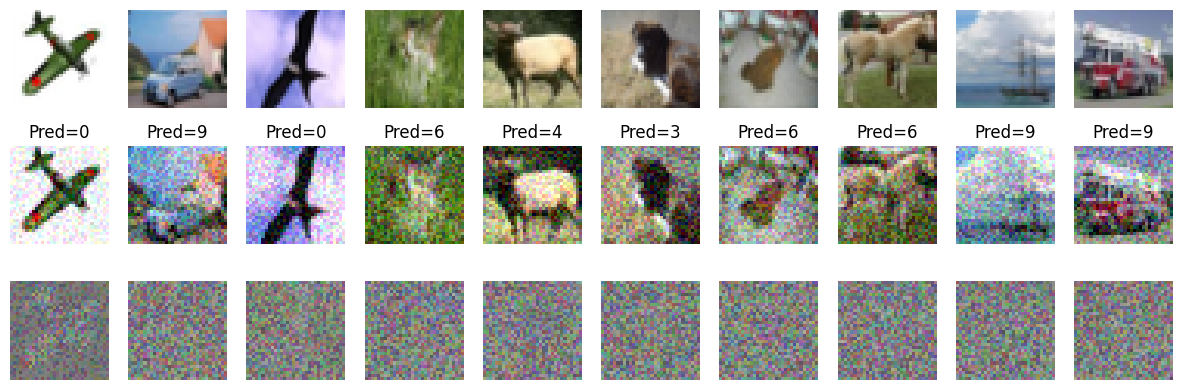

In [8]:
fig, ax = plt.subplots(
    3,
    10,
    figsize=(15, 5),
)

for col, index in enumerate(random_sel):
    ax[0, col].imshow(
        channels_last(
            X_test[index]
        )
    )
    ax[0, col].axis("off")

    ax[1, col].imshow(
        channels_last(
            random_result["images"][index]
        )
    )
    ax[1, col].set_title(
        f'Pred={random_result["predictions"][index]}'
    )
    ax[1, col].axis("off")

    ax[2, col].imshow(
        np.clip(
            channels_last(
                random_result["noise"][index]
            ) + 0.5,
            0,
            1,
        )
    )
    ax[2, col].axis("off")

plt.show()


# Fast Gradient Sign Method (FGSM)


In [9]:
def fgsm_untargeted(
    model,
    X,
    y,
    goal_accuracy=0.1,
    max_steps=200,
):
    X_grad = torch.tensor(
        X,
        dtype=torch.float32,
        device=device,
        requires_grad=True,
    )

    y_t = torch.tensor(
        y,
        dtype=torch.long,
        device=device,
    )

    model.zero_grad()

    logits = model(X_grad)

    loss = nn.CrossEntropyLoss()(
        logits,
        y_t,
    )
    loss.backward()

    grad_sign = (
        X_grad.grad
        .detach()
        .sign()
        .cpu()
        .numpy()
    )

    for i in range(1, max_steps):
        epsilon = i / max_steps

        X_adv = np.clip(
            X + epsilon * grad_sign,
            0.0,
            1.0,
        )

        with torch.no_grad():
            logits_adv = model(
                torch.tensor(
                    X_adv,
                    dtype=torch.float32,
                    device=device,
                )
            )

        pred = logits_adv.argmax(
            dim=1
        ).cpu().numpy()

        accuracy = accuracy_score(
            y,
            pred,
        )

        print(
            f"epsilon={epsilon:.4f}, "
            f"accuracy={accuracy:.4f}"
        )

        if accuracy < goal_accuracy:
            break

    return {
        "epsilon": epsilon,
        "accuracy": accuracy,
        "images": X_adv,
        "noise": X_adv - X,
        "predictions": pred,
    }


fgsm_result = fgsm_untargeted(
    model,
    X_test,
    y_test,
)

print("Confusion matrix:")
print(
    confusion_matrix(
        y_test,
        fgsm_result["predictions"],
    )
)


epsilon=0.0050, accuracy=0.4280
epsilon=0.0100, accuracy=0.2450
epsilon=0.0150, accuracy=0.1530
epsilon=0.0200, accuracy=0.1050
epsilon=0.0250, accuracy=0.0780
Confusion matrix:
[[ 8  8 23  6 13  1  0  4 22 18]
 [ 1  8  0  1  0  0  6  1  5 67]
 [14  1  9 21 20 10 13  9  2  1]
 [ 6  2  9  6 16 21 20 16  2  5]
 [ 5  0 19 14  4  6 22 19  0  1]
 [ 0  0 12 34 12  1 10 13  2  2]
 [ 0  4 28 31 25  6  6  9  1  2]
 [ 4  3 12 15 40 12  6  7  1  2]
 [39 15  8  6  3  0  3  2  7 23]
 [13 37  5  6  2  1  8  3 12 22]]


# Targeted FGSM


In [10]:
def fgsm_targeted(
    model,
    X,
    target_class=5,
    goal_target_rate=0.90,
    max_steps=100,
):
    X_grad = torch.tensor(
        X,
        dtype=torch.float32,
        device=device,
        requires_grad=True,
    )

    target = torch.full(
        (len(X),),
        int(target_class),
        dtype=torch.long,
        device=device,
    )

    model.zero_grad()

    logits = model(X_grad)

    loss = nn.CrossEntropyLoss()(
        logits,
        target,
    )
    loss.backward()

    grad_sign = (
        X_grad.grad
        .detach()
        .sign()
        .cpu()
        .numpy()
    )

    for i in range(1, max_steps):
        epsilon = i / max_steps

        X_adv = np.clip(
            X - epsilon * grad_sign,
            0.0,
            1.0,
        )

        with torch.no_grad():
            logits_adv = model(
                torch.tensor(
                    X_adv,
                    dtype=torch.float32,
                    device=device,
                )
            )

        pred = logits_adv.argmax(
            dim=1
        ).cpu().numpy()

        target_rate = np.mean(
            pred == target_class
        )

        print(
            f"epsilon={epsilon:.4f}, "
            f"target_rate={target_rate:.4f}"
        )

        if target_rate > goal_target_rate:
            break

    return {
        "epsilon": epsilon,
        "target_rate": target_rate,
        "images": X_adv,
        "noise": X_adv - X,
        "predictions": pred,
    }


fgsm_target_result = fgsm_targeted(
    model,
    X_test,
    target_class=5,
)

print(
    "Target-class confusion matrix:"
)
print(
    confusion_matrix(
        np.full_like(y_test, 5),
        fgsm_target_result["predictions"],
        labels=np.arange(10),
    )
)


epsilon=0.0100, target_rate=0.2670
epsilon=0.0200, target_rate=0.3170
epsilon=0.0300, target_rate=0.3080
epsilon=0.0400, target_rate=0.2650
epsilon=0.0500, target_rate=0.2310
epsilon=0.0600, target_rate=0.1910
epsilon=0.0700, target_rate=0.1580
epsilon=0.0800, target_rate=0.1330
epsilon=0.0900, target_rate=0.1090
epsilon=0.1000, target_rate=0.0880
epsilon=0.1100, target_rate=0.0770
epsilon=0.1200, target_rate=0.0600
epsilon=0.1300, target_rate=0.0520
epsilon=0.1400, target_rate=0.0380
epsilon=0.1500, target_rate=0.0310
epsilon=0.1600, target_rate=0.0280
epsilon=0.1700, target_rate=0.0230
epsilon=0.1800, target_rate=0.0170
epsilon=0.1900, target_rate=0.0160
epsilon=0.2000, target_rate=0.0120
epsilon=0.2100, target_rate=0.0090
epsilon=0.2200, target_rate=0.0090
epsilon=0.2300, target_rate=0.0060
epsilon=0.2400, target_rate=0.0030
epsilon=0.2500, target_rate=0.0030
epsilon=0.2600, target_rate=0.0030
epsilon=0.2700, target_rate=0.0020
epsilon=0.2800, target_rate=0.0010
epsilon=0.2900, targ

# Basic Iterative Method


In [11]:
def bim_untargeted(
    model,
    X,
    y,
    step_size=0.01,
    goal_accuracy=0.1,
    max_steps=200,
):
    X_adv = torch.tensor(
        X,
        dtype=torch.float32,
        device=device,
        requires_grad=True,
    )

    y_t = torch.tensor(
        y,
        dtype=torch.long,
        device=device,
    )

    for iteration in range(max_steps):
        logits = model(X_adv)

        pred = logits.argmax(
            dim=1
        ).detach().cpu().numpy()

        accuracy = accuracy_score(
            y,
            pred,
        )

        print(
            f"iteration={iteration:3d}, "
            f"accuracy={accuracy:.4f}"
        )

        if accuracy < goal_accuracy:
            break

        loss = nn.CrossEntropyLoss()(
            logits,
            y_t,
        )

        model.zero_grad()

        if X_adv.grad is not None:
            X_adv.grad.zero_()

        loss.backward()

        with torch.no_grad():
            X_adv += (
                step_size
                * X_adv.grad.sign()
            )
            X_adv.clamp_(0.0, 1.0)

    X_adv_np = (
        X_adv.detach()
        .cpu()
        .numpy()
    )

    return {
        "iterations": iteration,
        "accuracy": accuracy,
        "images": X_adv_np,
        "noise": X_adv_np - X,
        "predictions": pred,
    }


bim_result = bim_untargeted(
    model,
    X_test,
    y_test,
)

print("Confusion matrix:")
print(
    confusion_matrix(
        y_test,
        bim_result["predictions"],
    )
)


iteration=  0, accuracy=0.7720
iteration=  1, accuracy=0.2450
iteration=  2, accuracy=0.0370
Confusion matrix:
[[ 6  8 22  5 10  0  4  4 24 20]
 [ 1  7  0  1  0  0  6  1  5 68]
 [16  1  6 18 20 10 12 11  5  1]
 [ 6  4 13  0 14 23 18 19  2  4]
 [ 6  0 19 18  0  6 18 20  1  2]
 [ 1  1 13 30  9  0 11 18  1  2]
 [ 1  5 28 35 21  7  1  9  2  3]
 [ 5  5 14 15 40 13  3  4  1  2]
 [43 20  9  4  2  0  2  2  1 23]
 [18 42  5  5  0  2  7  4 14 12]]


# Targeted Basic Iterative Method


In [12]:
def bim_targeted(
    model,
    X,
    target_class=5,
    step_size=0.005,
    goal_target_rate=0.90,
    max_steps=200,
):
    X_adv = torch.tensor(
        X,
        dtype=torch.float32,
        device=device,
        requires_grad=True,
    )

    target = torch.full(
        (len(X),),
        int(target_class),
        dtype=torch.long,
        device=device,
    )

    for iteration in range(max_steps):
        logits = model(X_adv)

        pred = logits.argmax(
            dim=1
        ).detach().cpu().numpy()

        target_rate = np.mean(
            pred == target_class
        )

        print(
            f"iteration={iteration:3d}, "
            f"target_rate={target_rate:.4f}"
        )

        if target_rate > goal_target_rate:
            break

        loss = nn.CrossEntropyLoss()(
            logits,
            target,
        )

        model.zero_grad()

        if X_adv.grad is not None:
            X_adv.grad.zero_()

        loss.backward()

        with torch.no_grad():
            X_adv -= (
                step_size
                * X_adv.grad.sign()
            )
            X_adv.clamp_(0.0, 1.0)

    X_adv_np = (
        X_adv.detach()
        .cpu()
        .numpy()
    )

    return {
        "iterations": iteration,
        "target_rate": target_rate,
        "images": X_adv_np,
        "noise": X_adv_np - X,
        "predictions": pred,
    }


bim_target_result = bim_targeted(
    model,
    X_test,
    target_class=5,
)

print(
    "Target-class confusion matrix:"
)
print(
    confusion_matrix(
        np.full_like(y_test, 5),
        bim_target_result["predictions"],
        labels=np.arange(10),
    )
)


iteration=  0, target_rate=0.0630
iteration=  1, target_rate=0.1870
iteration=  2, target_rate=0.3860
iteration=  3, target_rate=0.5450
iteration=  4, target_rate=0.6630
iteration=  5, target_rate=0.7730
iteration=  6, target_rate=0.8460
iteration=  7, target_rate=0.9060
Target-class confusion matrix:
[[  0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0]
 [ 14   9  25  16   1 906   3   6   5  15]
 [  0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0]]


## Key Takeaways

The CIFAR-10 experiments preserve the same attack progression as MNIST while using a convolutional model and three-channel images. Random noise provides a non-adaptive baseline, FGSM uses one input-gradient direction, and BIM repeatedly recomputes gradients. Targeted attacks optimize predictions toward a chosen class rather than simply reducing clean accuracy.
